# Lesson 00: Histograms, Probability Distribution Functions (PDF), and Cumulative Distribution Functions (CDF)

## Overview

This lesson introduces the fundamental statistical concepts used to describe and interpret engineering data.

Using a dataset of annual peak streamflow observations, this notebook explores how descriptive statistics, histograms, probability distribution functions (PDF), and cumulative distribution functions (CDF) provide insight into the behavior and variability of hydrologic systems.

The objective is not simply to calculate statistical values, but to develop an intuitive understanding of what those values represent and how they support engineering decision making.

---

## Learning Objectives

By the end of this lesson, you should be able to:

- Load and inspect a dataset using Pandas.
- Compute basic descriptive statistics.
- Interpret the mean, median, variance, and standard deviation.
- Create and interpret a histogram.
- Understand the purpose of a Probability Distribution Function (PDF).
- Understand the purpose of a Cumulative Distribution Function (CDF).
- Estimate exceedance probabilities from a CDF.
- Relate statistical results to practical engineering applications.

---

## Dataset

The dataset contains twenty years of annual peak streamflow observations collected from a hypothetical stream gaging station.

| Variable | Description | Units |
|----------|-------------|-------|
| `year` | Observation year | — |
| `peak_flow_cfs` | Annual maximum streamflow | Cubic feet per second (cfs) |

---

## Engineering Scenario

A transportation agency is evaluating the replacement of an aging roadway culvert.

Before hydraulic modeling and design begin, engineers perform an exploratory statistical analysis of the historical streamflow record to better understand the characteristics of the watershed.

This notebook walks through the first step of that process.

---

## Notebook Outline

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis
4. Calculate Descriptive Statistics
5. Create and Interpret a Histogram
6. Estimate the Probability Distribution Function (PDF)
7. Construct the Cumulative Distribution Function (CDF)
8. Engineering Interpretation

---

> **Note**
>
> This notebook accompanies **Lesson 00** of the **Applied Statistics for Infrastructure Analytics** project. Detailed lesson objectives and discussion questions are available in:
>
> `docs/00_overview/00_problem_statement.md`

In [21]:
from applied_infrastructure_analytics.io.loaders import load_data
from applied_infrastructure_analytics.io.utils import descriptive_statistics
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator


## Load Dataset

In [22]:
DATA = Path("../../data/raw/hydrology/annual_peak_flow.csv")
df = load_data(DATA)

Dataset has been loaded as a Pandas Dataframe


## Exploratory Data Analysis

In [23]:
df.head()

,year,peak_flow_cfs
0,2005,412
1,2006,437
2,2007,455
3,2008,472
4,2009,489


In [24]:
df.tail()

,year,peak_flow_cfs
15,2020,691
16,2021,724
17,2022,771
18,2023,845
19,2024,936


In [25]:
print(df.dtypes)

year             int64
peak_flow_cfs    int64
dtype: object


## Calculate Descriptive Statistics

In [26]:
stats = descriptive_statistics(df)
print(stats)

   observations    mean  median  minimum  maximum  range  variance    std_dev
0            20  599.25   570.0      412      936    524  19401.25  139.28837


In [27]:
df.describe()

,year,peak_flow_cfs
count,20.00000,20.00000
mean,2014.50000,599.25000
std,5.91608,139.28837
min,2005.00000,412.00000
25%,2009.75000,499.50000
50%,2014.50000,570.00000
75%,2019.25000,669.25000
max,2024.00000,936.00000


## Create and Interpret Histogram

## Part 2 – Histogram

Create a histogram of the annual peak flows.

Use an appropriate number of bins.

Answer the following questions:

- Where do most observations occur?
- Is the data approximately symmetric?
- Does the distribution appear skewed?
- Are high-flow events common or rare?

Record your observations before continuing.

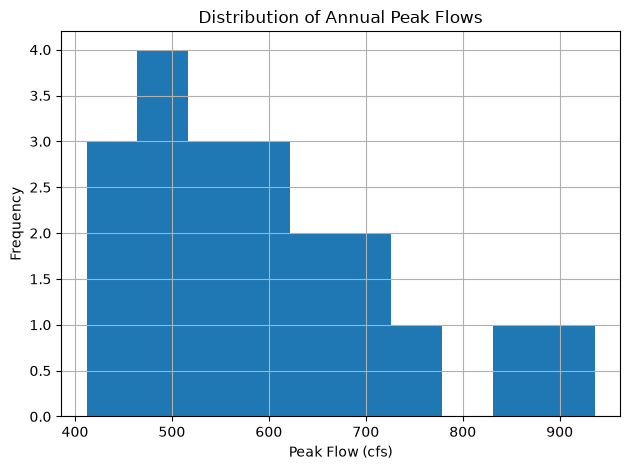

In [28]:
flow_stats = df["peak_flow_cfs"]
flow_stats.hist(bins=10, legend=False)
plt.xlabel("Peak Flow (cfs)")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Peak Flows")
plt.tight_layout()
plt.show()

### Scatter Plot

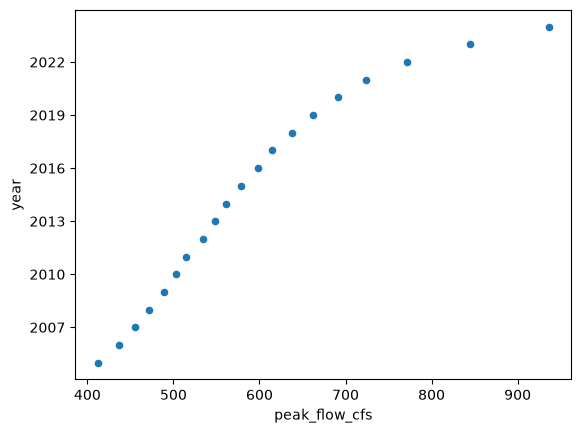

In [29]:
ax = df.plot.scatter(x="peak_flow_cfs", y="year")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

### Histogram

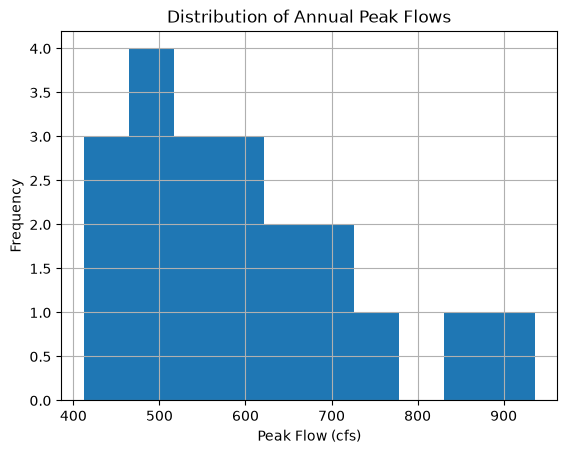

In [30]:
df['peak_flow_cfs'].hist(bins=10)
plt.xlabel("Peak Flow (cfs)")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Peak Flows")
plt.show()



### Histogram
- More scalable method
- Use the object-oriented Matplotlib API (fig, ax).
- Nearly all professional examples use it because it makes it much easier to create multiple plots, customize formatting, and avoid unexpected behavior.
- It also plays nicely with the kind of reusable plotting functions you'll likely add to your repository later.

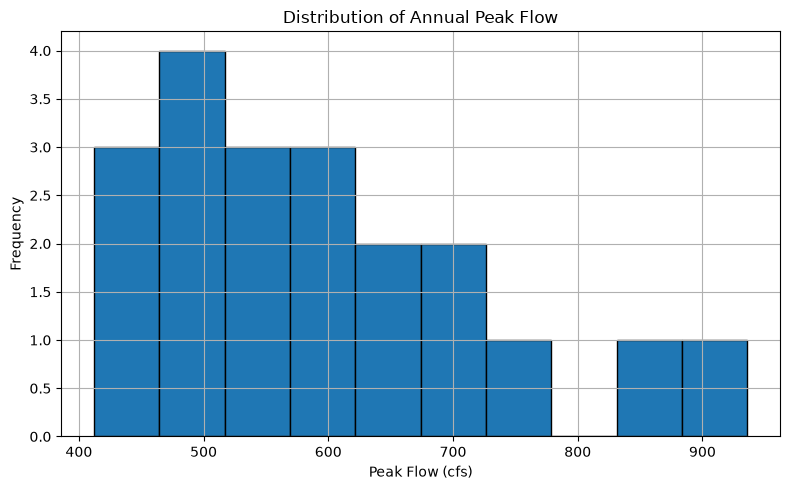

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

df["peak_flow_cfs"].hist(
    bins=10,
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribution of Annual Peak Flow")
ax.set_xlabel("Peak Flow (cfs)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Data Documentation & Interpretation

Questions to consider:

- Does the dataset appear reasonable?
- Are there any obvious outliers?
- Are values evenly distributed?
- Where do most observations occur?
- Is the data approximately symmetric?
- Does the distribution appear skewed?
- Are high-flow events common or rare?

- Does the dataset appear reasonable?<br>**Answer:** The data seems reasonable with the range and distribution of flows shown in the histogram.
- Are there any obvious outliers?<br>**Answer:** The dataset has higher flows, but nothing unreasonable to believe there are outliers.
- Are values evenly distributed?<br>**Answer:** Values appear to be reasonably distributed, though the distribution is not uniform.
- Where do most observations occur?<br>**Answer:** Most observations appear in the 400 - 600 cfs range.
- Is the data approximately symmetric?<br>**Answer:** Data is not symmetric.
- Does the distribution appear skewed?<br>**Answer:** The distribution is right skewed.
- Are high-flow events common or rare?<br>
**Answer:** High flow events are rare.

### Part 2 – Summary
The distribution of annual peak flows is positively (right) skewed, with most observations clustered between approximately 450 and 650 cfs and a small number of unusually large peak flow events extending the upper tail.

# Probability Density Function (PDF)

## Part 3 – Probability Density Function (PDF)

Estimate the Probability Density Function for the observed data.

Overlay the PDF on the histogram.

Without using mathematical definitions, answer:

- What does the PDF tell you about the streamflow record?
- Which flow values appear most likely?
- Which flow values appear least likely?

Think about how this differs from the histogram.

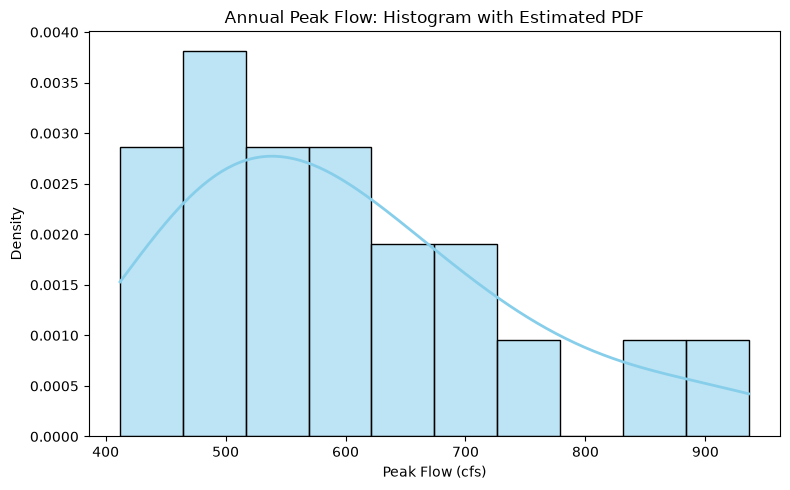

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="peak_flow_cfs",
    bins=10,
    stat="density",  # normalize histogram so area is 1 (PDF scale)
    kde=True,
    color="skyblue",
    edgecolor="black",
    alpha=0.55,
    line_kws={"color": "darkred", "linewidth": 2},
    ax=ax,
)

ax.set_title("Annual Peak Flow: Histogram with Estimated PDF")
ax.set_xlabel("Peak Flow (cfs)")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


### Part 3 - Code Breakdown
- `fig, ax = plt.subplots(figsize=(8, 5))` creates a figure and axis using the object-oriented plotting style.
- `sns.histplot(...)` draws the histogram from `peak_flow_cfs`.
- `bins=10` splits the flow range into 10 intervals so you can compare how often values fall in each range.
- `stat="density"` rescales bar heights from counts to density, so the histogram can be compared directly with a PDF.
- `kde=True` adds a smooth curve (kernel density estimate) that serves as an estimated PDF from the sample.
- `alpha=0.55` makes the histogram bars semi-transparent so the PDF curve stays visible.
- `line_kws={"color": "darkred", "linewidth": 2}` styles the PDF curve to be dark red and thicker for emphasis.
- `ax=ax` tells Seaborn to draw on the specific Matplotlib axis you created with `plt.subplots(...)`.
- Axis titles and labels make the plot interpretable in engineering units.


### Part 3 - Interpretation
- The PDF gives a smooth view of where flow values are concentrated in the record.
- The highest-density region (most likely values) is in the mid-range flows.
- The lowest-density region (least likely values) is in the extreme high-flow tail.
- Compared to the histogram, the PDF is less sensitive to bin edges and easier to read as a continuous pattern.

<h1 style="color: blue;">Cumulative Density Function (CDF)</h1>

## Part 4 – Cumulative Density Function (CDF)

Construct the empirical CDF.

Using the CDF, estimate:

- P(Flow ≤ 600 cfs)
- P(Flow ≤ 700 cfs)
- P(Flow > 700 cfs)
- P(Flow > 800 cfs)

Describe what each probability means in plain English.

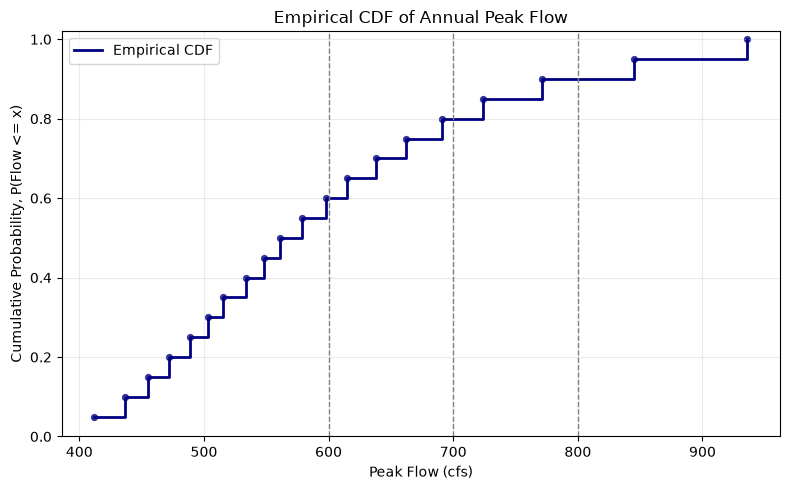

P(Flow <= 600 cfs) = 0.60
P(Flow <= 700 cfs) = 0.80
P(Flow > 700 cfs)  = 0.20
P(Flow > 800 cfs)  = 0.10


In [33]:
flows = np.sort(df["peak_flow_cfs"].to_numpy())
n = len(flows)
ecdf = np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(8, 5))

ax.step(flows, ecdf, where="post", color="navy", linewidth=2, label="Empirical CDF")
ax.scatter(flows, ecdf, color="navy", s=18, alpha=0.7)

for threshold in [600, 700, 800]:
    ax.axvline(threshold, color="gray", linestyle="--", linewidth=1)

ax.set_title("Empirical CDF of Annual Peak Flow")
ax.set_xlabel("Peak Flow (cfs)")
ax.set_ylabel("Cumulative Probability, P(Flow <= x)")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

p_le_600 = (df["peak_flow_cfs"] <= 600).mean()
p_le_700 = (df["peak_flow_cfs"] <= 700).mean()
p_gt_700 = (df["peak_flow_cfs"] > 700).mean()
p_gt_800 = (df["peak_flow_cfs"] > 800).mean()

print(f"P(Flow <= 600 cfs) = {p_le_600:.2f}")
print(f"P(Flow <= 700 cfs) = {p_le_700:.2f}")
print(f"P(Flow > 700 cfs)  = {p_gt_700:.2f}")
print(f"P(Flow > 800 cfs)  = {p_gt_800:.2f}")


### Part 4 - Code Breakdown
- `flows = np.sort(df["peak_flow_cfs"].to_numpy())` converts the flow column to a NumPy array and sorts it from smallest to largest.
- `n = len(flows)` stores the sample size (number of years).
- `ecdf = np.arange(1, n + 1) / n` computes cumulative probability levels (1/n, 2/n, ..., n/n).
- `ax.step(..., where="post")` draws the empirical CDF as a staircase function.
- `ax.scatter(...)` adds points at each observed flow, showing the discrete sample behind the staircase.
- `ax.axvline(...)` adds reference lines at 600, 700, and 800 cfs to make probability reads easier.
- `ax.set_ylabel("Cumulative Probability, P(Flow <= x)")` defines the CDF axis meaning directly on the figure.
- Probability lines like `(df["peak_flow_cfs"] <= 700).mean()` compute fractions of years meeting a condition; this is exactly an empirical probability.


### Part 4 - Interpretation
- `P(Flow <= 600 cfs) = 0.60`: About 60% of years have peak flow at or below 600 cfs.
- `P(Flow <= 700 cfs) = 0.80`: About 80% of years have peak flow at or below 700 cfs.
- `P(Flow > 700 cfs) = 0.20`: About 20% of years exceed 700 cfs.
- `P(Flow > 800 cfs) = 0.10`: About 10% of years exceed 800 cfs.